In [1]:
import pickle 
import pandas as pd 
import os 


with open("pickles_DOBNA/summary_data.pkl", "rb") as f: 
    data = pickle.load(f)


In [2]:
print(os.getcwd())


/media/sf_VirtualShared/ratcliff-group-resources/workflows/TADF_HTVS


In [3]:
summary_data_df = pd.DataFrame(data)
summary_data_df.columns


Index(['Name', 'SMILES', 'Eliminated?', 'Ionic?',
       'Contains Small/Large/No Rings?', 'Number of Atoms',
       'Tanimoto Similarity', 'SAscore', 'FF Converged?', 'Connected?',
       'Non-Overlapping?', 'XTB Converged?', 'xTB HOMO-LUMO gap / eV',
       'HOMO-LUMO Converged?', 'HOMO-LUMO Force / eV/A', 'HOMO-LUMO Gap / eV',
       'HOMO-LUMO Overlap', 'HOMO / eV', 'LUMO / eV'],
      dtype='object')

In [4]:


xtb = pd.read_csv("dobna_homo_lumo_ev.csv")




In [5]:
import re

summary_data_df = summary_data_df.loc[:, ~summary_data_df.columns.duplicated()].copy()


if "id" not in summary_data_df.columns:
    summary_data_df = summary_data_df.reset_index().rename(columns={"index": "id"})


junk = [c for c in summary_data_df.columns
        if re.match(r"^(HOMO_xtb_eV|LUMO_xtb_eV)(_.+)?$", str(c))]
if junk:
    summary_data_df = summary_data_df.drop(columns=junk)


summary_data_df["id"] = pd.to_numeric(summary_data_df["id"], errors="coerce").astype("Int64")

xtb = xtb.reset_index(drop=True).copy()
xtb.columns = xtb.columns.astype(str).str.strip()
xtb["id"] = pd.to_numeric(xtb["id"], errors="coerce").astype("Int64")


xtb_merge = xtb[["id", "HOMO_eV", "LUMO_eV"]].copy()
xtb_merge["HOMO_xtb_eV"] = pd.to_numeric(xtb_merge["HOMO_eV"], errors="coerce")
xtb_merge["LUMO_xtb_eV"] = pd.to_numeric(xtb_merge["LUMO_eV"], errors="coerce")
xtb_merge = xtb_merge[["id", "HOMO_xtb_eV", "LUMO_xtb_eV"]]

summary_data_df = summary_data_df.merge(xtb_merge, on="id", how="left")

summary_data_df.head(50)



,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,XTB Converged?,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV
0,0,DOBNA,N#Cc1cc(-n2c3ccccc3c3ccccc32)c(-n2c3ccccc3c3cc...,False,False,False,54,1.0,2.290449,True,...,True,1.992498,True,2.368887,2.132728,0.458662,-5.507698,-3.37497,NaN,NaN
1,1,DOBNA_1,Cc1cccc2c3ccccc3n(C=C(C#N)C(C#N)=CC=C=CN3c4ccc...,True,False,True,61,0.314815,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,DOBNA_2,N#CC1=C2Cc3ccccc3N2c2cc(C#N)c(cc2-n2c3ccccc3c3...,True,False,True,56,0.58209,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,DOBNA_3,C=CC=CC=CC1C=CC2CN1C(C=CC)=C(Nn1c3ccccc3c3cccc...,True,False,False,63,0.268293,5.333928,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,DOBNA_4,N#Cc1cc(-n2c3c(c4ccccc42)=[C+]C=CC=3)c(-n2c3cc...,True,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,DOBNA_5,CC=CC=C1C=[P+](C)C=CC=CN1c1cc(C#N)c(C#N)cc1-n1...,True,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,DOBNA_6,N#Cc1cc(-n2ccccccc3ccccc32)c(-n2c3ccccc3c3cccc...,True,False,True,56,0.723577,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,DOBNA_7,N#Cc1cc(Nc2ccccc2C2=C=CC=CC2)c(-n2c3ccccc3c3cc...,True,False,False,56,0.593985,3.322122,True,...,True,0.983793,True,2.294354,1.134779,0.658515,-5.220981,-4.086202,-9.9512,-8.9674
8,8,DOBNA_8,C=C(C#N)C(C#N)=CC=C=Cc1ccccc1-c1ccccc1,True,False,NaN,37,0.219858,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,DOBNA_9,CC=CCN=C1CN(C#P2C=C(C)C(C#N)=CC2n2c3ccccc3c3cc...,True,False,False,64,0.380645,4.635707,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
homo_lumo_df = summary_data_df[summary_data_df["xTB HOMO-LUMO gap / eV"].notna()]
homo_lumo_df["xTB HOMO-LUMO gap / eV"].describe()

count    607.000000
mean       1.811387
std        0.539534
min        0.091863
25%        1.502298
50%        1.834101
75%        2.151437
max        3.242073
Name: xTB HOMO-LUMO gap / eV, dtype: float64

In [7]:
homo_lumo_df

,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,XTB Converged?,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV
0,0,DOBNA,N#Cc1cc(-n2c3ccccc3c3ccccc32)c(-n2c3ccccc3c3cc...,False,False,False,54,1.0,2.290449,True,...,True,1.992498,True,2.368887,2.132728,0.458662,-5.507698,-3.37497,NaN,NaN
7,7,DOBNA_7,N#Cc1cc(Nc2ccccc2C2=C=CC=CC2)c(-n2c3ccccc3c3cc...,True,False,False,56,0.593985,3.322122,True,...,True,0.983793,True,2.294354,1.134779,0.658515,-5.220981,-4.086202,-9.9512,-8.9674
10,10,DOBNA_10,C=CC=C1CN(c2cc(C#N)c(C#N)cc2-n2c3ccccc3c3ccccc...,False,False,False,55,0.625,3.015315,True,...,True,1.825435,True,2.337168,2.007729,0.484677,-5.153059,-3.145331,-9.9911,-8.1657
16,16,DOBNA_16,C#CC=c1c(=C)c2ccccc2n1-c1cc(C#N)c(C#N)cc1-n1c2...,False,False,False,54,0.721311,3.245154,True,...,True,1.715652,True,2.353184,1.885965,0.611378,-5.186174,-3.300209,-9.9825,-8.2669
17,17,DOBNA_17,Cc1c(C#N)c(C#N)cc(-n2c3ccccc3c3ccccc32)c1-n1c2...,False,False,False,57,0.798319,2.677576,True,...,True,1.955313,True,2.358521,2.041095,0.390193,-5.410625,-3.369529,-10.2939,-8.3386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1980,DOBNA_1980,Cc1cc(Nc2ccccc2C=C2C=CC=CN2)c(-n2c3ccccc3c3ccc...,True,False,False,62,0.462585,3.179373,True,...,True,2.060603,True,2.62542,2.021912,0.69324,-4.006717,-1.984805,-8.9282,-6.8676
1983,1983,DOBNA_1983,N#Cc1cc(N2C=CC=CC2)c(-n2c3ccccc3c3ccccc32)cc1C#N,False,False,False,45,0.591667,2.904557,True,...,True,1.837393,True,2.331957,2.004776,0.570132,-5.205568,-3.200792,-9.9993,-8.1619
1992,1992,DOBNA_1992,N#Cc1cc(N2C3=CC=CCC3c3ccccc32)c(-n2c3ccccc3c3c...,False,False,False,56,0.643411,3.459861,True,...,True,1.467144,True,2.349763,1.556766,0.439657,-4.854989,-3.298223,-9.7242,-8.2571
1993,1993,DOBNA_1993,C=Nc1cc(N=CC=CC=Cc2ccccc2C)c(N2c3ccccc3CC2C=CC...,False,False,False,63,0.254545,4.047134,True,...,True,1.167107,True,2.242559,1.229898,0.420775,-4.51728,-3.287382,-9.3642,-8.1971


Text(0, 0.5, 'Number of molecules')

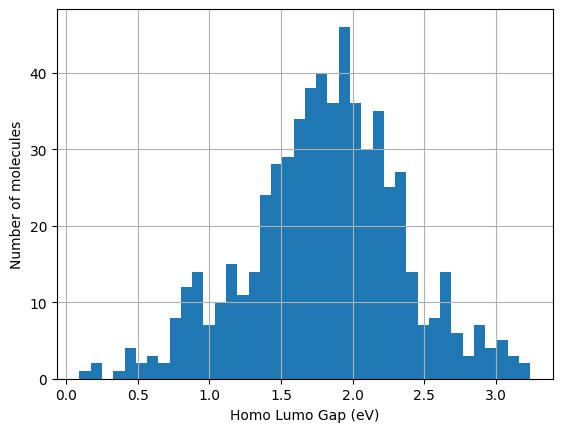

In [8]:
import matplotlib.pyplot as plt

homo_lumo_df["xTB HOMO-LUMO gap / eV"].hist(bins=40)
plt.xlabel ('Homo Lumo Gap (eV)')
plt.ylabel ('Number of molecules')


<Axes: xlabel='Number of Atoms', ylabel='xTB HOMO-LUMO gap / eV'>

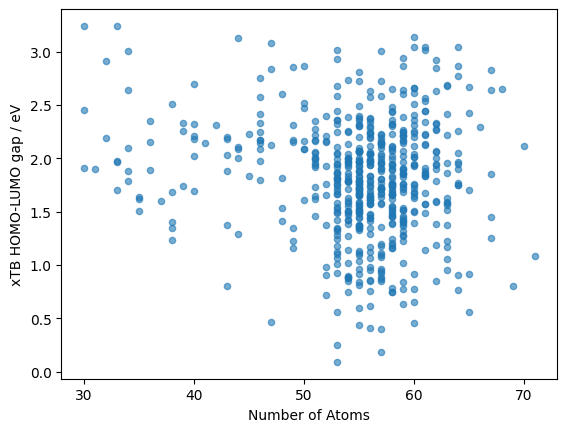

In [9]:
homo_lumo_df.plot.scatter(
    x='Number of Atoms',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

<Axes: xlabel='SAscore', ylabel='xTB HOMO-LUMO gap / eV'>

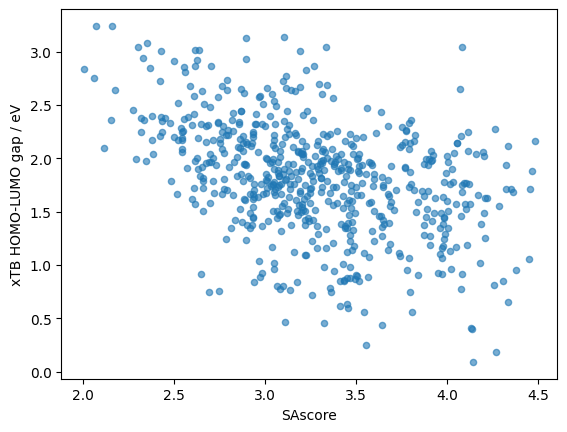

In [10]:
homo_lumo_df.plot.scatter(
    x='SAscore',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

In [11]:
homo_lumo_df.dtypes

id                                  Int64
Name                               object
SMILES                             object
Eliminated?                          bool
Ionic?                               bool
Contains Small/Large/No Rings?     object
Number of Atoms                    object
Tanimoto Similarity                object
SAscore                            object
FF Converged?                      object
Connected?                         object
Non-Overlapping?                   object
XTB Converged?                     object
xTB HOMO-LUMO gap / eV            float64
HOMO-LUMO Converged?               object
HOMO-LUMO Force / eV/A             object
HOMO-LUMO Gap / eV                 object
HOMO-LUMO Overlap                  object
HOMO / eV                          object
LUMO / eV                          object
HOMO_xtb_eV                       float64
LUMO_xtb_eV                       float64
dtype: object

In [12]:
summary_data_df.dtypes


id                                  Int64
Name                               object
SMILES                             object
Eliminated?                          bool
Ionic?                               bool
Contains Small/Large/No Rings?     object
Number of Atoms                    object
Tanimoto Similarity                object
SAscore                            object
FF Converged?                      object
Connected?                         object
Non-Overlapping?                   object
XTB Converged?                     object
xTB HOMO-LUMO gap / eV            float64
HOMO-LUMO Converged?               object
HOMO-LUMO Force / eV/A             object
HOMO-LUMO Gap / eV                 object
HOMO-LUMO Overlap                  object
HOMO / eV                          object
LUMO / eV                          object
HOMO_xtb_eV                       float64
LUMO_xtb_eV                       float64
dtype: object

In [13]:
cols_to_numeric = [
    "Number of Atoms",
    "SAscore",
    "Tanimoto Similarity",
    "xTB HOMO-LUMO gap / eV"
]

for col in cols_to_numeric:
    homo_lumo_df.loc[:, col] = pd.to_numeric(homo_lumo_df[col], errors="coerce")

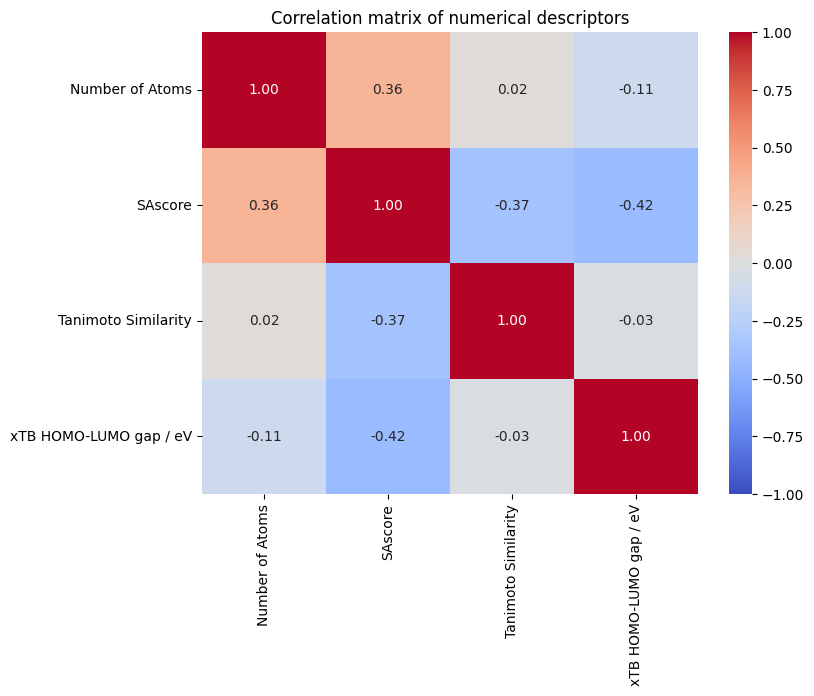

In [14]:
corr = homo_lumo_df[cols_to_numeric].corr()

import seaborn as sns 
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap= "coolwarm",
    annot=True,
    fmt=".2f",
    vmin= -1,
    vmax=1
)
plt.title("Correlation matrix of numerical descriptors")
plt.show()


In [15]:
homo_lumo_df


,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,XTB Converged?,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV
0,0,DOBNA,N#Cc1cc(-n2c3ccccc3c3ccccc32)c(-n2c3ccccc3c3cc...,False,False,False,54,1.0,2.290449,True,...,True,1.992498,True,2.368887,2.132728,0.458662,-5.507698,-3.37497,NaN,NaN
7,7,DOBNA_7,N#Cc1cc(Nc2ccccc2C2=C=CC=CC2)c(-n2c3ccccc3c3cc...,True,False,False,56,0.593985,3.322122,True,...,True,0.983793,True,2.294354,1.134779,0.658515,-5.220981,-4.086202,-9.9512,-8.9674
10,10,DOBNA_10,C=CC=C1CN(c2cc(C#N)c(C#N)cc2-n2c3ccccc3c3ccccc...,False,False,False,55,0.625,3.015315,True,...,True,1.825435,True,2.337168,2.007729,0.484677,-5.153059,-3.145331,-9.9911,-8.1657
16,16,DOBNA_16,C#CC=c1c(=C)c2ccccc2n1-c1cc(C#N)c(C#N)cc1-n1c2...,False,False,False,54,0.721311,3.245154,True,...,True,1.715652,True,2.353184,1.885965,0.611378,-5.186174,-3.300209,-9.9825,-8.2669
17,17,DOBNA_17,Cc1c(C#N)c(C#N)cc(-n2c3ccccc3c3ccccc32)c1-n1c2...,False,False,False,57,0.798319,2.677576,True,...,True,1.955313,True,2.358521,2.041095,0.390193,-5.410625,-3.369529,-10.2939,-8.3386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1980,DOBNA_1980,Cc1cc(Nc2ccccc2C=C2C=CC=CN2)c(-n2c3ccccc3c3ccc...,True,False,False,62,0.462585,3.179373,True,...,True,2.060603,True,2.62542,2.021912,0.69324,-4.006717,-1.984805,-8.9282,-6.8676
1983,1983,DOBNA_1983,N#Cc1cc(N2C=CC=CC2)c(-n2c3ccccc3c3ccccc32)cc1C#N,False,False,False,45,0.591667,2.904557,True,...,True,1.837393,True,2.331957,2.004776,0.570132,-5.205568,-3.200792,-9.9993,-8.1619
1992,1992,DOBNA_1992,N#Cc1cc(N2C3=CC=CCC3c3ccccc32)c(-n2c3ccccc3c3c...,False,False,False,56,0.643411,3.459861,True,...,True,1.467144,True,2.349763,1.556766,0.439657,-4.854989,-3.298223,-9.7242,-8.2571
1993,1993,DOBNA_1993,C=Nc1cc(N=CC=CC=Cc2ccccc2C)c(N2c3ccccc3CC2C=CC...,False,False,False,63,0.254545,4.047134,True,...,True,1.167107,True,2.242559,1.229898,0.420775,-4.51728,-3.287382,-9.3642,-8.1971


In [16]:
false_rows = homo_lumo_df[homo_lumo_df["HOMO-LUMO Converged?"] == False]
homo_lumo_df = homo_lumo_df.drop(false_rows.index)


In [17]:
cols = [
    "xTB HOMO-LUMO gap / eV",
    "HOMO-LUMO Gap / eV"
]

for col in cols:
    homo_lumo_df[col] = pd.to_numeric(homo_lumo_df[col], errors = "coerce")
    

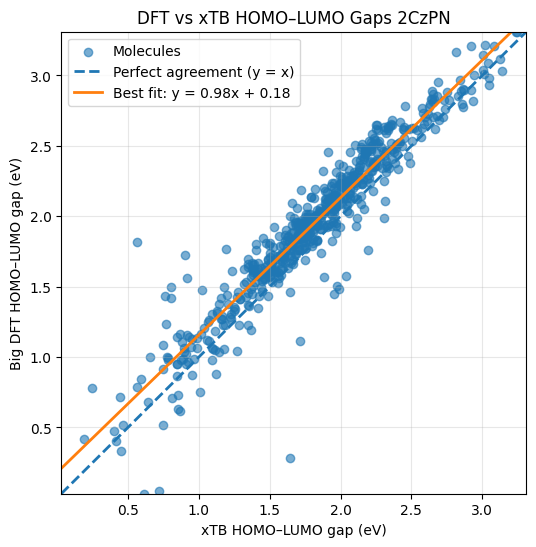

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

tmp = homo_lumo_df[
    ["xTB HOMO-LUMO gap / eV", "HOMO-LUMO Gap / eV"]
].apply(pd.to_numeric, errors="coerce").dropna()

x = tmp["xTB HOMO-LUMO gap / eV"]
y = tmp["HOMO-LUMO Gap / eV"]


plt.figure(figsize=(6, 6))

plt.scatter(x, y, alpha=0.6, label="Molecules")

min_gap = min(x.min(), y.min())
max_gap = max(x.max(), y.max())

plt.plot(
    [min_gap, max_gap],
    [min_gap, max_gap],
    "--",
    linewidth=2,
    label="Perfect agreement (y = x)"
)


m, b = np.polyfit(x, y, 1)

plt.plot(
    [min_gap, max_gap],
    [m * min_gap + b, m * max_gap + b],
    linewidth=2,
    label=f"Best fit: y = {m:.2f}x + {b:.2f}"
)


plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("Big DFT HOMO–LUMO gap (eV)")
plt.title("DFT vs xTB HOMO–LUMO Gaps 2CzPN")

plt.xlim(min_gap, max_gap)
plt.ylim(min_gap, max_gap)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:

ids = [774, 269, 1821, 501, 1361]
for id in ids:
    row = homo_lumo_df[homo_lumo_df['id'] == id]
    print(f"2CzPN_{id}:", row['SMILES'].values[0])

2CzPN_774: N#CC1=C=C(n2c3ccccc3c3c(-n4c5ccccc5c5ccccc54)cccc32)C=C1C#N
2CzPN_269: N#Cc1cc(-n2c3c(c4ccccc42)=CCB=C=3)c(-n2c3ccccc3c3ccccc32)cc1C#N
2CzPN_1821: Cc1cc(Nc2ccccc2CC2=[PH]=CC=CC2)c(N=Nc2ccccc2-c2ccccc2)cc1C#N
2CzPN_501: CCOCC=C1CN(c2cc(C)c(NC)cc2N=Nc2ccccc2-c2ccccc2)c2ccccc21
2CzPN_1361: N#Cc1cc(N=Nc2ccccc2-c2ccccc2)c(-n2c3ccccc3c3ccccc32)cc1C#N


In [20]:
corr = homo_lumo_df["xTB HOMO-LUMO gap / eV"].corr(
    homo_lumo_df["HOMO-LUMO Gap / eV"]
)

print(corr)  

0.9489268623892322


In [21]:
homo_lumo_df["Gap difference / eV"] = (
    homo_lumo_df["HOMO-LUMO Gap / eV"]
    - homo_lumo_df["xTB HOMO-LUMO gap / eV"]
)

homo_lumo_df["Gap difference / eV"].describe()



count    605.000000
mean       0.137232
std        0.174023
min       -1.361791
25%        0.068622
50%        0.145315
75%        0.222540
max        1.255986
Name: Gap difference / eV, dtype: float64

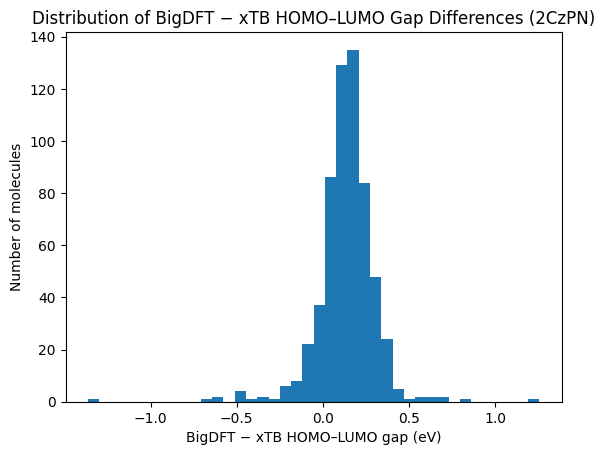

In [22]:
plt.hist(homo_lumo_df["Gap difference / eV"], bins=40)
plt.xlabel("BigDFT − xTB HOMO–LUMO gap (eV)")
plt.ylabel("Number of molecules")
plt.title("Distribution of BigDFT − xTB HOMO–LUMO Gap Differences (2CzPN)")
plt.show()

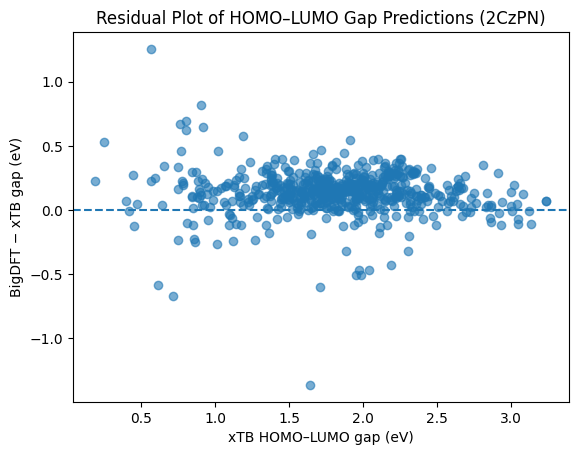

In [23]:

plt.scatter(
    homo_lumo_df["xTB HOMO-LUMO gap / eV"],
    homo_lumo_df["Gap difference / eV"],
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("BigDFT − xTB gap (eV)")
plt.title("Residual Plot of HOMO–LUMO Gap Predictions (2CzPN)")
plt.show()

In [26]:


outliers = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=False).index
)

outliers.head(5)




,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
774,774,DOBNA_774,N#CC1=C=C(n2c3ccccc3c3c(-n4c5ccccc5c5ccccc54)c...,False,False,False,51,0.645669,3.227324,True,...,1.643530,True,2.296535,0.281739,0.345022,-5.454267,-5.172529,-10.1607,-8.5171,-1.361791
269,269,DOBNA_269,N#Cc1cc(-n2c3c(c4ccccc42)=CCB=C=3)c(-n2c3ccccc...,False,False,False,53,0.723577,3.543041,True,...,0.562247,True,2.312499,1.818233,0.432641,-5.16677,-3.348537,-8.6720,-8.1098,1.255986
1821,1821,DOBNA_1821,Cc1cc(Nc2ccccc2CC2=[PH]=CC=CC2)c(N=Nc2ccccc2-c...,False,False,False,64,0.34375,3.836867,True,...,0.902449,True,2.279504,1.722115,0.583753,-5.097544,-3.375429,-9.1614,-8.2590,0.819666
501,501,DOBNA_501,CCOCC=C1CN(c2cc(C)c(NC)cc2N=Nc2ccccc2-c2ccccc2...,True,False,False,69,0.29697,3.100367,True,...,0.802600,True,1.458438,1.495029,0.684166,-4.222814,-2.727785,-8.5099,-7.7073,0.692429
1361,1361,DOBNA_1361,N#Cc1cc(N=Nc2ccccc2-c2ccccc2)c(-n2c3ccccc3c3cc...,False,False,False,56,0.666667,2.747213,True,...,0.760095,True,2.30643,1.432521,0.574364,-5.452492,-4.019971,-9.7711,-9.0110,0.672426


In [27]:





closest = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=True).index
)

closest.head(5) 

,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
1213,1213,DOBNA_1213,N#Cc1cc(-n2c3ccccc3c3ccccc32)c(-n2c3ccccc3c3cc...,False,False,False,56,0.843478,2.76268,True,...,1.661836,True,2.257685,1.663024,0.391094,-5.301868,-3.638844,-10.1223,-8.4605,0.001188
919,919,DOBNA_919,N#CC(=C=Cn1c2ccccc2c2ccccc21)C(C#N)=CCn1c2cccc...,False,False,False,56,0.558824,3.077059,True,...,1.831534,True,2.382231,1.830031,0.260301,-5.232044,-3.402013,-10.0552,-8.2236,-0.001503
1850,1850,DOBNA_1850,C=C=CC=C1CN(C2=C(c3ccccc3-c3ccccc3)C=CCC2C#N)c...,True,False,False,57,0.309677,3.794903,True,...,2.143101,True,2.329361,2.141431,0.7133,-4.45291,-2.311479,-9.2755,-7.1324,-0.001670
715,715,DOBNA_715,C=Nc1cc(N2C3=CC=CC3c3ccccc32)c(-n2c3ccccc3c3cc...,False,False,False,60,0.471831,3.589359,True,...,1.935186,True,1.069677,1.932807,0.223676,-4.40856,-2.475753,-9.3018,-7.3666,-0.002379
902,902,DOBNA_902,CCC=CC=Cc1ccccc1Nc1cc(C#N)c(N)cc1-n1c2ccccc2c2...,False,False,False,61,0.464789,2.858516,True,...,2.342574,True,2.217898,2.339611,0.563117,-4.750651,-2.41104,-9.5711,-7.2285,-0.002963


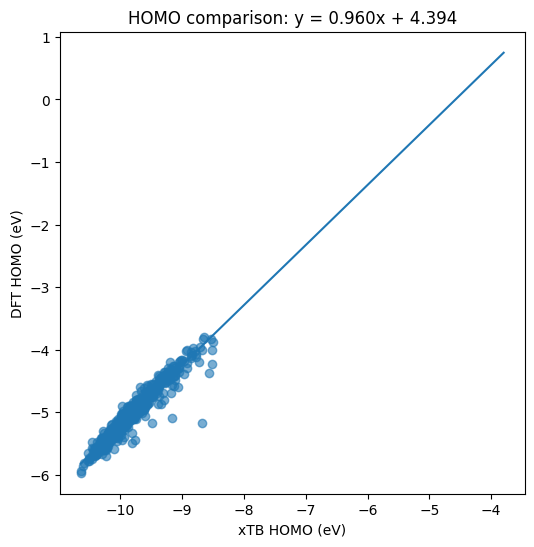

HOMO slope: 0.9602238304345828
HOMO intercept: 4.394047312836958
Points used: 604


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tmp = homo_lumo_df[["HOMO_xtb_eV", "HOMO / eV"]].copy()
tmp["HOMO_xtb_eV"] = pd.to_numeric(tmp["HOMO_xtb_eV"], errors="coerce")
tmp["HOMO / eV"]   = pd.to_numeric(tmp["HOMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["HOMO_xtb_eV"].to_numpy()
y = tmp["HOMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())




m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB HOMO (eV)")
plt.ylabel("DFT HOMO (eV)")
plt.title(f"HOMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("HOMO slope:", m)
print("HOMO intercept:", b)
print("Points used:", len(tmp))


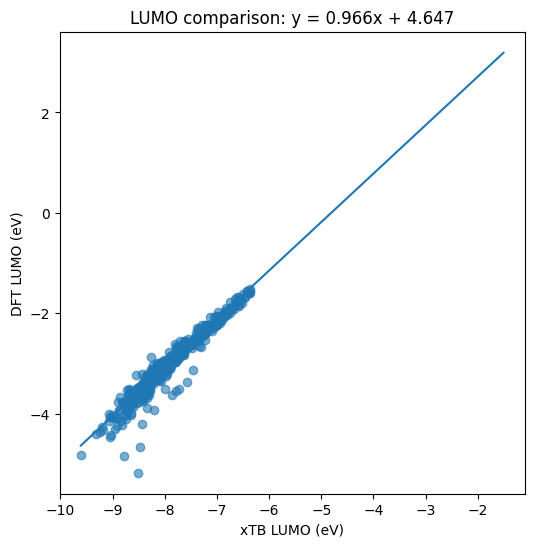

LUMO slope: 0.9656959168825825
LUMO intercept: 4.647097882577306
Points used: 604


In [29]:
tmp = homo_lumo_df[["LUMO_xtb_eV", "LUMO / eV"]].copy()
tmp["LUMO_xtb_eV"] = pd.to_numeric(tmp["LUMO_xtb_eV"], errors="coerce")
tmp["LUMO / eV"]   = pd.to_numeric(tmp["LUMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["LUMO_xtb_eV"].to_numpy()
y = tmp["LUMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())


m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB LUMO (eV)")
plt.ylabel("DFT LUMO (eV)")
plt.title(f"LUMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("LUMO slope:", m)
print("LUMO intercept:", b)
print("Points used:", len(tmp))


In [30]:

mismatch_df = homo_lumo_df.copy()


for c in ["HOMO_xtb_eV", "LUMO_xtb_eV", "HOMO / eV", "LUMO / eV"]:
    mismatch_df[c] = pd.to_numeric(mismatch_df[c], errors="coerce")


mismatch_df["delta_HOMO_xtb_minus_dft_eV"] = (
    mismatch_df["HOMO_xtb_eV"] - mismatch_df["HOMO / eV"]
)

mismatch_df["delta_LUMO_xtb_minus_dft_eV"] = (
    mismatch_df["LUMO_xtb_eV"] - mismatch_df["LUMO / eV"]
)

mismatch_df["abs_delta_HOMO_eV"] = mismatch_df["delta_HOMO_xtb_minus_dft_eV"].abs()
mismatch_df["abs_delta_LUMO_eV"] = mismatch_df["delta_LUMO_xtb_minus_dft_eV"].abs()


i_h = mismatch_df["abs_delta_HOMO_eV"].idxmax()
i_l = mismatch_df["abs_delta_LUMO_eV"].idxmax()

biggest_homo = mismatch_df.loc[
    i_h,
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

biggest_lumo = mismatch_df.loc[
    i_l,
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Biggest HOMO xTB–DFT mismatch:")
print(biggest_homo)

print("\nBiggest LUMO xTB–DFT mismatch:")
print(biggest_lumo) 

Biggest HOMO xTB–DFT mismatch:
id                                  601
HOMO_xtb_eV                     -9.6912
HOMO / eV                     -4.605614
delta_HOMO_xtb_minus_dft_eV   -5.085586
abs_delta_HOMO_eV              5.085586
Name: 601, dtype: object

Biggest LUMO xTB–DFT mismatch:
id                                 1125
LUMO_xtb_eV                     -8.2569
LUMO / eV                     -2.871981
delta_LUMO_xtb_minus_dft_eV   -5.384919
abs_delta_LUMO_eV              5.384919
Name: 1125, dtype: object


In [31]:





N = 10  

top_homo = mismatch_df.sort_values(
    "abs_delta_HOMO_eV", ascending=False 
).head(N)[
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

top_lumo = mismatch_df.sort_values(
    "abs_delta_LUMO_eV", ascending=False
).head(N)[
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Top HOMO mismatches:")
display(top_homo)

print("\nTop LUMO mismatches:")
display(top_lumo)

Top HOMO mismatches:


,id,HOMO_xtb_eV,HOMO / eV,delta_HOMO_xtb_minus_dft_eV,abs_delta_HOMO_eV
601,601,-9.6912,-4.605614,-5.085586,5.085586
1106,1106,-9.9818,-4.896256,-5.085544,5.085544
1159,1159,-9.7419,-4.718646,-5.023254,5.023254
1829,1829,-9.2016,-4.197819,-5.003781,5.003781
370,370,-9.5731,-4.571106,-5.001994,5.001994
282,282,-9.6605,-4.660986,-4.999514,4.999514
604,604,-9.6105,-4.615180,-4.995320,4.995320
1430,1430,-10.2836,-5.296453,-4.987147,4.987147
856,856,-9.8817,-4.899531,-4.982169,4.982169
1737,1737,-9.3890,-4.409051,-4.979949,4.979949



Top LUMO mismatches:


,id,LUMO_xtb_eV,LUMO / eV,delta_LUMO_xtb_minus_dft_eV,abs_delta_LUMO_eV
1125,1125,-8.2569,-2.871981,-5.384919,5.384919
1014,1014,-8.5445,-3.229844,-5.314656,5.314656
1110,1110,-8.4308,-3.205274,-5.225526,5.225526
1819,1819,-8.7301,-3.516489,-5.213611,5.213611
1147,1147,-7.7984,-2.599843,-5.198557,5.198557
1936,1936,-8.8539,-3.660648,-5.193252,5.193252
311,311,-8.2164,-3.031894,-5.184506,5.184506
1297,1297,-8.6864,-3.510437,-5.175963,5.175963
1261,1261,-7.7020,-2.544662,-5.157338,5.157338
856,856,-8.1438,-2.989307,-5.154493,5.154493


In [32]:

i_h_close = mismatch_df["abs_delta_HOMO_eV"].idxmin()
closest_homo = mismatch_df.loc[
    i_h_close,
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]


i_l_close = mismatch_df["abs_delta_LUMO_eV"].idxmin()
closest_lumo = mismatch_df.loc[
    i_l_close,
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Closest HOMO xTB–DFT match:")
print(closest_homo)

print("\nClosest LUMO xTB–DFT match:")
print(closest_lumo)

Closest HOMO xTB–DFT match:
id                                 269
HOMO_xtb_eV                     -8.672
HOMO / eV                     -5.16677
delta_HOMO_xtb_minus_dft_eV   -3.50523
abs_delta_HOMO_eV              3.50523
Name: 269, dtype: object

Closest LUMO xTB–DFT match:
id                                  774
LUMO_xtb_eV                     -8.5171
LUMO / eV                     -5.172529
delta_LUMO_xtb_minus_dft_eV   -3.344571
abs_delta_LUMO_eV              3.344571
Name: 774, dtype: object


In [33]:
N = 10  
closest_homo_N = mismatch_df.sort_values(
    "abs_delta_HOMO_eV", ascending=True
).head(N)[
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

closest_lumo_N = mismatch_df.sort_values(
    "abs_delta_LUMO_eV", ascending=True
).head(N)[
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Top closest HOMO matches:")
display(closest_homo_N)

print("\nTop closest LUMO matches:")
display(closest_lumo_N)

Top closest HOMO matches:


,id,HOMO_xtb_eV,HOMO / eV,delta_HOMO_xtb_minus_dft_eV,abs_delta_HOMO_eV
269,269,-8.6720,-5.166770,-3.505230,3.505230
1821,1821,-9.1614,-5.097544,-4.063856,4.063856
135,135,-8.5667,-4.374491,-4.192209,4.192209
501,501,-8.5099,-4.222814,-4.287086,4.287086
906,906,-9.4954,-5.181193,-4.314207,4.314207
1361,1361,-9.7711,-5.452492,-4.318608,4.318608
905,905,-9.8193,-5.487068,-4.332232,4.332232
1973,1973,-9.0623,-4.597699,-4.464601,4.464601
354,354,-9.3387,-4.867538,-4.471162,4.471162
1459,1459,-9.8154,-5.329932,-4.485468,4.485468



Top closest LUMO matches:


,id,LUMO_xtb_eV,LUMO / eV,delta_LUMO_xtb_minus_dft_eV,abs_delta_LUMO_eV
774,774,-8.5171,-5.172529,-3.344571,3.344571
1643,1643,-8.4718,-4.651722,-3.820078,3.820078
1555,1555,-8.7848,-4.836272,-3.948528,3.948528
1642,1642,-7.7169,-3.515085,-4.201815,4.201815
1705,1705,-7.5791,-3.357907,-4.221193,4.221193
188,188,-7.8535,-3.630961,-4.222539,4.222539
239,239,-7.7752,-3.550413,-4.224787,4.224787
1540,1540,-8.4414,-4.207284,-4.234116,4.234116
1947,1947,-8.2148,-3.931621,-4.283179,4.283179
268,268,-7.4503,-3.128442,-4.321858,4.321858
